<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/MULTIPLE_LINEAR_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/london_merged.csv')
df.head(10)

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0
5,2015-01-04 05:00:00,46,2.0,2.0,93.0,4.0,1.0,0.0,1.0,3.0
6,2015-01-04 06:00:00,51,1.0,-1.0,100.0,7.0,4.0,0.0,1.0,3.0
7,2015-01-04 07:00:00,75,1.0,-1.0,100.0,7.0,4.0,0.0,1.0,3.0
8,2015-01-04 08:00:00,131,1.5,-1.0,96.5,8.0,4.0,0.0,1.0,3.0
9,2015-01-04 09:00:00,301,2.0,-0.5,100.0,9.0,3.0,0.0,1.0,3.0


In [4]:
df = pd.read_csv('/content/Ecommerce Customers.csv')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


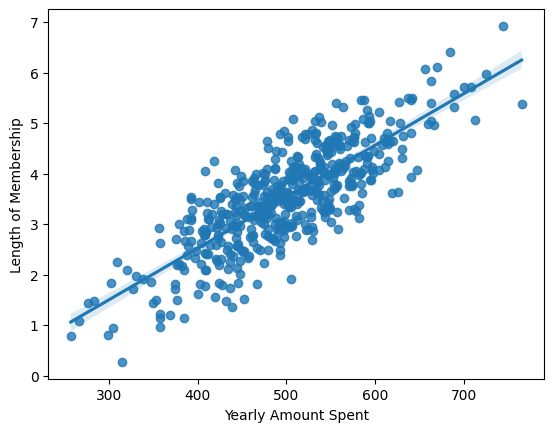

In [12]:
sns.regplot(x="Yearly Amount Spent",y="Length of Membership",data=df);

In [15]:
x = df.iloc[:,3:-1].values #get all row data for 'Avg Session Length', 'Time on App' , 'Time on website' and 'Length of Membership
y = df.iloc[:,-1].values #get the last column depentant variable data for all rows

In [16]:
print(x[:10,:])
print(y[:10])

[[34.49726773 12.65565115 39.57766802  4.08262063]
 [31.92627203 11.10946073 37.26895887  2.66403418]
 [33.00091476 11.33027806 37.11059744  4.1045432 ]
 [34.30555663 13.71751367 36.72128268  3.12017878]
 [33.33067252 12.79518855 37.5366533   4.44630832]
 [33.87103788 12.02692534 34.47687763  5.4935072 ]
 [32.0215955  11.36634831 36.68377615  4.68501725]
 [32.73914294 12.35195897 37.37335886  4.43427343]
 [33.9877729  13.38623528 37.53449734  3.27343358]
 [31.93654862 11.81412829 37.14516822  3.20280607]]
[587.95105397 392.20493344 487.54750487 581.85234404 599.40609205
 637.10244792 521.57217476 549.90414611 570.20040896 427.1993849 ]


**Data Preprocessing**

In [19]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan,strategy='mean')
#missing vals and calc mean for 1st and 2nd cols
imputer.fit(x[:,:])
#tranform method wil replace missing val with calc val in 1st(age) and 2nd(salary) cols
x[:,:] = imputer.transform(x[:,:])

print(x[:10,:])

[[34.49726773 12.65565115 39.57766802  4.08262063]
 [31.92627203 11.10946073 37.26895887  2.66403418]
 [33.00091476 11.33027806 37.11059744  4.1045432 ]
 [34.30555663 13.71751367 36.72128268  3.12017878]
 [33.33067252 12.79518855 37.5366533   4.44630832]
 [33.87103788 12.02692534 34.47687763  5.4935072 ]
 [32.0215955  11.36634831 36.68377615  4.68501725]
 [32.73914294 12.35195897 37.37335886  4.43427343]
 [33.9877729  13.38623528 37.53449734  3.27343358]
 [31.93654862 11.81412829 37.14516822  3.20280607]]


In [20]:
#splitting the dataset into training and test set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [22]:
#Build Model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [23]:
#predicting the test set results
y_pred = regressor.predict(x_test)


In [26]:
#Evaluate Model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, confusion_matrix, classification_report
r2_score(y_test,y_pred)
#predicting the test set results
y_pred = regressor.predict(x_test)
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

92.89010304498552
7.6456747989153175


In [27]:
# Splitting the dataset into training and test set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state = 0)

#Build Model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train,y_train)

#predicting the test set results
y_pred = regressor.predict(x_test)


# Evaluate Model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report
r2_score(y_test,y_pred)

mean_absolute_error(y_test,y_pred)

mean_squared_error(y_test,y_pred)

94.5577947927327